# 15. A custom bootstrap

<div class="callout callout-note">
Language: <strong>Python</strong> (Jupyter) - <a href="r.qmd">R version</a>
</div>

`bootstrap_analysis()` puts a confidence interval on a fitted distribution's quantiles. That is
the question flood frequency asks most often, but it is the only question that verb answers,
because the statistic is built into it. `bootstrap_custom()` lifts that restriction. You write
the resampling rule, the fitting rule and the statistic as ordinary Python functions, and the
ported Numerics bootstrap calls them, so any quantity you can compute from a fitted parameter
set can be given an interval. All four upstream delegates (`ResampleFunction`, `FitFunction`,
`StatisticFunction` and `JackknifeFunction`) and all five interval methods are reachable this
way. Like example 13, it has no upstream counterpart: the USACE-RMC Numerics-Python-Examples
repository has no bootstrap notebook.

## What you'll learn

- Put a confidence interval on a statistic the package has no verb for: here the annual
  probability of exceeding a fixed discharge under a fitted distribution.
- The exact signature of each of the four functions, which is the likeliest thing to get wrong.
- Draw inside `resample` with `rng.integers()`, off the generator the replicate hands you, and
  never with `random` or `numpy.random`.
- Compare all five interval methods on one bootstrap, and read what their disagreement means.
- Where the cross-language guarantee stops on the callback path, and how to write functions that
  keep it.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import corehydropy as ch

## A statistic the package does not provide

Forty years of annual peak discharge, drawn from a log-normal population through the seeded core
so the R twin has the identical record. `LnNormal` is parameterized by the REAL-space mean and
standard deviation, not by the log-space ones, following the C# class it is ported from.

In [2]:
peaks = ch.Distribution("LnNormal", [12000, 5200]).random(40, seed=2026)
print(f"n = {len(peaks)}, mean = {np.mean(peaks):.1f} cfs, max = {max(peaks):.1f} cfs")

n = 40, mean = 12871.5 cfs, max = 27919.2 cfs


The design question is not "what is the 100-year flood", it is "how often does this levee
overtop". The levee crest passes 25,000 cfs, so the statistic wanted is the annual exceedance
probability of 25,000 cfs under the fitted distribution:

$$
p = 1 - F(25{,}000 \mid \hat{\theta})
$$

`bootstrap_analysis()` cannot express this. It inverts the fitted distribution at a probability
and gives an interval on the resulting discharge; here the discharge is fixed by the levee and
the probability is the unknown. The point estimate is one line.

In [3]:
threshold = 25000
fitted = ch.Distribution.fit("LnNormal", peaks, method="mle")
p_hat = 1 - fitted.cdf(threshold)
print(f"Fitted LnNormal: mean = {fitted.params[0]:.1f}, sd = {fitted.params[1]:.1f}")
print(f"P(peak > {threshold}) = {p_hat:.5f}, about 1 in {1 / p_hat:.1f} years")

Fitted LnNormal: mean = 12888.2, sd = 5789.1
P(peak > 25000) = 0.03922, about 1 in 25.5 years


That single number carries no indication of how firmly 40 observations pin it down, which is
what the bootstrap is for.

## The three functions

`resample`, `fit` and `statistic` are required; `jackknife` is a fourth, used only by `"BCa"`.
Their argument orders are given in `help(ch.bootstrap_custom)`, and the C++ side cannot tell a
swapped pair from a deliberate one, so they are worth reading rather than guessing.

`resample(data, parameters, rng)` returns one bootstrap sample. `rng` is a handle on THIS
replicate's generator. Draw from it with `rng.integers()` or `rng.uniform()`. Using `random` or
`numpy.random` instead would draw from Python's own random state, and the run would stop being
reproducible and stop agreeing with R. `rng.integers()` draws on `[min, max)` counting from 0,
matching the ported `MersenneTwister.Next(minInclusive, maxExclusive)`, which is already
Python's subscript convention.

In [4]:
def resample_iid(data, parameters, rng):
    return [data[k] for k in rng.integers(len(data), 0, len(data))]

`fit(data)` returns the parameter vector, and `statistic(parameters)` turns a parameter vector
into the numbers to be given intervals. Splitting the work this way is what lets the bootstrap
report an interval on the parameters and on the statistic from the same replicates.

In [5]:
def fit_lnnormal(data):
    return ch.Distribution.fit("LnNormal", data, method="mle").params


def exceedance(parameters):
    return [1 - ch.Distribution("LnNormal", parameters).cdf(threshold)]

`jackknife(data, index)` returns `data` with observation `index` left out, and `index` counts
from 0. In Python that is `data[:index] + data[index + 1:]`, which needs `data` to be a list
rather than a NumPy array for `+` to mean concatenation.

In [6]:
def leave_one_out(data, index):
    data = list(data)
    return data[:index] + data[index + 1:]

## Run the bootstrap

Four hundred replicates, seeded. Each one calls `resample`, then `fit`, then `statistic`, so the
cost of a run is 400 crossings back into Python plus the fit inside each.

In [7]:
boot = ch.bootstrap_custom(
    data=peaks,
    resample=resample_iid,
    fit=fit_lnnormal,
    statistic=exceedance,
    replicates=400,
    alpha=0.1,
    ci_method="Percentile",
    seed=2026,
)

print(f"estimate       {boot['estimate'][0]:.5f}")
print(f"90% interval   [{boot['lower'][0]:.5f}, {boot['upper'][0]:.5f}]")
print(f"standard error {boot['standard_error'][0]:.5f}")
bias = boot["mean"][0] - boot["estimate"][0]
print(f"replicate mean {boot['mean'][0]:.5f}  (bias {bias:+.5f})")
print(f"valid / failed {boot['valid_count'][0]} / {boot['failed_replicates']}")

estimate       0.03922
90% interval   [0.01368, 0.07445]
standard error 0.01889
replicate mean 0.03976  (bias +0.00054)
valid / failed 400 / 0


Two fields deserve attention. `estimate` is the statistic of the ORIGINAL fit, not an average
over replicates, so it is exactly the `p_hat` computed above. `mean` is the average over the
valid replicates, and the gap between the two is the bootstrap bias estimate. It is small and
positive here, which says the resampled fits sit slightly further into the tail than the
original does.

The interval is the useful output. A best estimate near 1 in 25 years, with a 90% interval
running from roughly 1 in 73 to roughly 1 in 13, is a very different design statement from the
point estimate on its own.

In [8]:
print(f"Return period: best {1 / boot['estimate'][0]:.1f} yr, "
      f"interval [{1 / boot['upper'][0]:.1f}, {1 / boot['lower'][0]:.1f}] yr")

Return period: best 25.5 yr, interval [13.4, 73.1] yr


The parameters get the same treatment from the same replicates.

In [9]:
print(f"{'parameter':>9} {'estimate':>10} {'lower':>10} {'upper':>10}")
for name, est, lo, hi in zip(["mean", "sd"], boot["parameter_estimate"],
                             boot["parameter_lower"], boot["parameter_upper"]):
    print(f"{name:>9} {est:>10.2f} {lo:>10.2f} {hi:>10.2f}")

parameter   estimate      lower      upper
     mean   12888.24   11590.24   14578.71
       sd    5789.06    4461.01    6962.87


## Comparing the five interval methods

The replicates do not change; only the rule for turning them into two endpoints does.
`"Percentile"` reads the two order statistics straight off the sorted replicates.
`"BiasCorrected"` shifts the two probabilities by the fraction of replicates below the original
estimate, which corrects for a skewed replicate distribution. `"Normal"` and `"BootstrapT"` work
on the ported cube-root transform of the statistic, and `"BootstrapT"` runs the studentized
workflow, nesting `inner_replicates` further resample-and-fit pairs inside every replicate.
`"BCa"` adds an acceleration term estimated by leave-one-out, and it is the only method that
calls `jackknife`. The other four ignore that argument entirely, so passing it costs nothing.

`"BootstrapT"` is the expensive one. With the ported defaults it would run 10,000 times 300
inner fits, so `inner_replicates` is dropped to 25 here to keep the page fast.

In [10]:
methods = ["Percentile", "BiasCorrected", "Normal", "BootstrapT", "BCa"]
intervals = []
for m in methods:
    r = ch.bootstrap_custom(
        data=peaks, resample=resample_iid, fit=fit_lnnormal, statistic=exceedance,
        jackknife=leave_one_out, replicates=400, alpha=0.1, ci_method=m,
        inner_replicates=25, seed=2026,
    )
    intervals.append({"method": m, "lower": r["lower"][0], "upper": r["upper"][0],
                      "width": r["upper"][0] - r["lower"][0],
                      "return_low": 1 / r["upper"][0], "return_high": 1 / r["lower"][0]})

header = f"{'method':>13} {'lower':>9} {'upper':>9} {'width':>9} {'return_low':>11} {'return_high':>12}"
print(header)
for row in intervals:
    print(f"{row['method']:>13} {row['lower']:>9.6f} {row['upper']:>9.6f} "
          f"{row['width']:>9.6f} {row['return_low']:>11.3f} {row['return_high']:>12.3f}")

       method     lower     upper     width  return_low  return_high
   Percentile  0.013685  0.074451  0.060766      13.432       73.074
BiasCorrected  0.016640  0.080509  0.063869      12.421       60.096
       Normal  0.015159  0.080623  0.065464      12.403       65.968
   BootstrapT  0.014280  0.092215  0.077935      10.844       70.028
          BCa  0.017966  0.083167  0.065200      12.024       55.660


All five share the same lower end to within about half a percentage point of exceedance
probability. They part company at the upper end, which is the tail of a right-skewed replicate
distribution, and that is exactly where a method's treatment of skew shows up. `"Percentile"`
gives the narrowest interval because it applies no correction at all; `"BiasCorrected"` and
`"BCa"` shift the window upward to account for the skew; `"BootstrapT"` is the widest, which is
its usual behavior on small samples and is not by itself a sign of anything wrong.

The spread across methods is worth reporting. When five defensible rules applied to one set of
replicates disagree by this much, the honest reading is that 40 observations do not determine
the tail probability tightly, not that one of the five is the right answer.

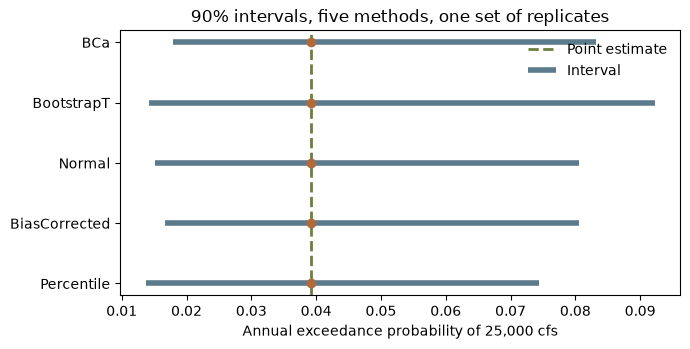

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.6))
y = np.arange(len(intervals))
ax.axvline(boot["estimate"][0], color="#6b7f3f", linestyle="--", linewidth=2,
           label="Point estimate")
ax.hlines(y, [row["lower"] for row in intervals], [row["upper"] for row in intervals],
          color="#5b7a8c", linewidth=4, label="Interval")
ax.plot([boot["estimate"][0]] * len(intervals), y, "o", color="#b06a3b")
ax.set_yticks(y)
ax.set_yticklabels([row["method"] for row in intervals])
ax.set_xlabel("Annual exceedance probability of 25,000 cfs")
ax.set_title("90% intervals, five methods, one set of replicates")
ax.legend(loc="upper right", frameon=False)
fig.tight_layout()
plt.show()

## What reproduces across languages, and what does not

Every other page on this site can promise that a seeded run gives bit-identical numbers in R and
Python, because every operation on those pages happens inside the shared C++ core and the two
packages call the same compiled code. The callback path is the one place that promise needs a
condition attached, and it is better stated plainly than buried.

The resampled INDICES still come from the core generator. `rng.integers()` reaches the same
seeded Mersenne Twister in both languages, so a given seed selects the identical observations in
the identical order, replicate for replicate. That half is unconditional. The other half is not:
`fit` and `statistic` are your own Python or R code, and the two languages do not guarantee
identical rounding for the same formula. A run reproduces across languages if and only if your
functions return bit-identical values.

Three rules cover almost every case:

1. `+`, `-`, `*` and `/` are IEEE-deterministic. Written the same way, they give the same bits
   in both languages.
2. `log`, `exp`, `sqrt`, `pow` and friends come from each platform's own math library. They are
   accurate but not required to round identically, so they can differ in the last bit.
3. R's `sum()` and `mean()` accumulate in extended precision where Python's do not. An explicit
   loop is the portable spelling of a sum on both sides.

A bootstrap is more forgiving of a differing last bit than MCMC is. One flipped bit perturbs one
replicate, and the ordering of the other 399 is untouched, so the interval usually moves by
nothing or by one order statistic. MCMC has no such tolerance: one flipped accept-or-reject
decision changes every state after it, and the chains diverge outright. The rule is the same in
both cases, but the consequence of breaking it is much louder in the MCMC one.

The callbacks on this page delegate their arithmetic back to the compiled core
(`Distribution.fit()` and `Distribution.cdf()` are core code called through Python), so this
page's numbers do in fact match the R twin's exactly. That is a measured property of these
particular functions, not something the package can promise about any function you write.
Because of it, the reproduction check below uses a fit written from arithmetic alone, where the
guarantee holds by construction.

## Key takeaways

1. `bootstrap_custom()` gives a confidence interval to anything computable from a fitted
   parameter set, not only to the quantiles `bootstrap_analysis()` knows about.
2. Get the four signatures from the documentation. `resample(data, parameters, rng)`,
   `fit(data)`, `statistic(parameters)`, `jackknife(data, index)` with `index` counting from 0.
3. Draw inside `resample` from the `rng` handle you are given. Anything else silently breaks
   reproducibility, in a way no error message will report.
4. Run more than one interval method. Their disagreement is information about the sample, and on
   a right-skewed statistic it is usually concentrated in the upper endpoint.
5. On the callback path, cross-language reproduction is conditional on your own arithmetic.
   Arithmetic-only functions keep it; `log` and `exp` and language-native summation need not.

## Reproduction check

The block below has two halves, and they carry different weight.

The first half pins this page's own statistic, the exceedance probability and its interval. Those
are a regression on this file: nothing upstream computes them, so they check that the page still
produces what it produced when it was written.

The second half pins the construct the package's own cross-language fixture pins. Eight-point
sample, iid resample off the core generator, a fit that is the sample mean summed in an explicit
loop, the identity statistic, 200 replicates at seed 12345. Those are exactly the callbacks
described above as safe: no `log`, no `exp`, no `sum()`. The same construct appears in
`fixtures/callback/callback_cross_language.json`, where it is asserted at ZERO tolerance, meaning
bit equality rather than a tolerance, and reproduced bit for bit by all four runners: the C++
fixture harness, R, Python and the dotnet oracle emitter driving the real C# `Bootstrap` class.
The values below were read from that library. Here they are checked at 1e-15 relative, matching
the R twin, which needs the tolerance because R's decimal parser can land one ulp off a written
literal.

In [12]:
def near(x, literal, tol=1e-15):
    return abs(x / literal - 1) < tol


x = [4.1, 5.2, 4.8, 5.5, 4.9, 5.1, 5.3, 4.7]


def mean_fit(data):
    acc = 0.0
    for xi in data:
        acc += xi
    return [acc / len(data)]


check = ch.bootstrap_custom(
    data=x,
    resample=resample_iid,
    fit=mean_fit,
    statistic=lambda parameters: parameters,
    replicates=200,
    alpha=0.1,
    ci_method="Percentile",
    seed=12345,
)

bca = [row for row in intervals if row["method"] == "BCa"][0]

# This page's own statistic: a within-Python regression, not an upstream literal (see above).
assert near(boot["estimate"][0], 0.039215959337224993)
assert near(boot["estimate"][0], p_hat)
assert near(boot["lower"][0], 0.013684822676157921)
assert near(boot["upper"][0], 0.074451060952393025)
assert near(boot["standard_error"][0], 0.018886626681229177)
assert near(boot["mean"][0], 0.039757148419774853)
assert boot["valid_count"][0] == 400
assert boot["failed_replicates"] == 0
assert near(bca["lower"], 0.017966299726084607)
assert near(bca["upper"], 0.083166540758831606)

# The cross-language construct, read from the real C# Bootstrap class and pinned at zero
# tolerance in fixtures/callback/callback_cross_language.json.
assert near(check["estimate"][0], 4.95)
assert near(check["lower"][0], 4.750000000000001)
assert near(check["upper"][0], 5.175)
assert near(check["standard_error"][0], 0.1408037320342551)
assert near(check["mean"][0], 4.961249999999999)
assert check["valid_count"][0] == 200
assert check["failed_replicates"] == 0
assert near(check["parameter_lower"][0], 4.750000000000001)

print("All reproduction checks passed.")

All reproduction checks passed.
